# Interpretation 

In [3]:
%%capture
%run model_training.ipynb
%run evaluation.ipynb

In [5]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import joblib
from sklearn.metrics import mean_squared_error
from pathlib import Path

Although final performance is reported using a stacked ensemble, global interpretability analysis is conducted on the base learners.
This allows examination of how different model classes (tree-based vs neural) capture relationships between input features and the target.
The stacking layer operates on model predictions rather than original features and is therefore not directly interpretable in feature space.

SHAP for LightGBM


In [6]:
path = Path(r"C:\Users\ASUS\Documents\Deep_Learning\boston_housing_project\models\final_stack_model.pkl")
model = StackingBlender.load(path)
random.seed(42)

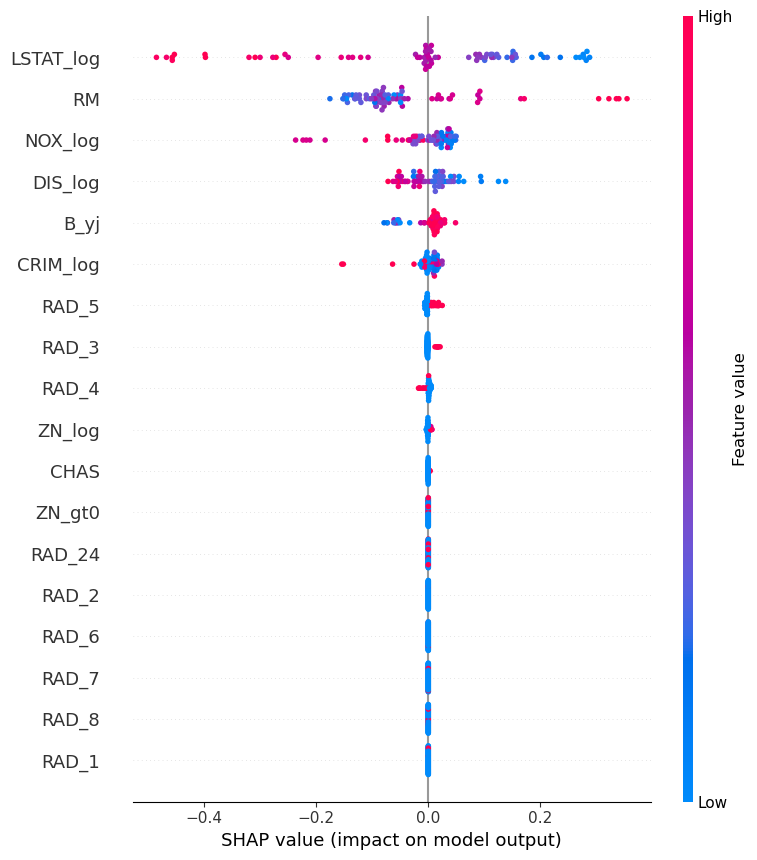

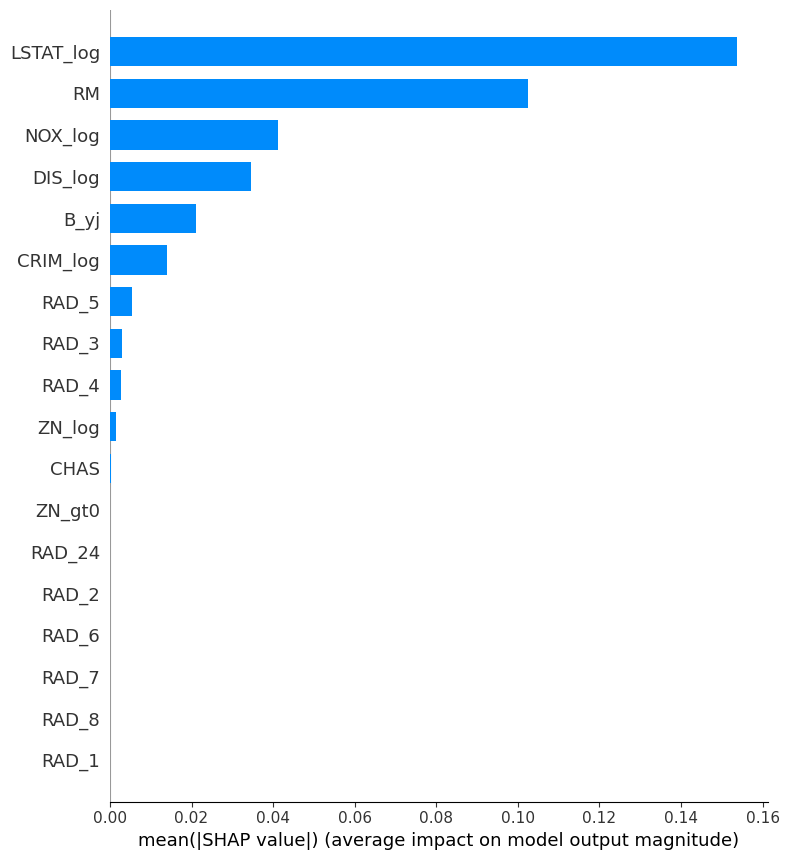

In [7]:
# SHAP for LightGBM
X_background = X_train_transformed
X_shap = X_val_transformed

lgb_explainer = shap.TreeExplainer(
    lgb_model,
    data=X_background
)

lgb_shap_values = lgb_explainer.shap_values(X_shap)
lgb_importance = (
    pd.DataFrame({
        "feature": X_val_transformed.columns,
        "importance": np.abs(lgb_shap_values).mean(axis=0)
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

shap.summary_plot(
    lgb_shap_values,
    X_shap,
    feature_names=X_shap.columns
)

shap.summary_plot(
    lgb_shap_values,
    X_shap,
    feature_names=X_shap.columns,
    plot_type="bar"
)

lgb_top10 = lgb_importance.head(10)


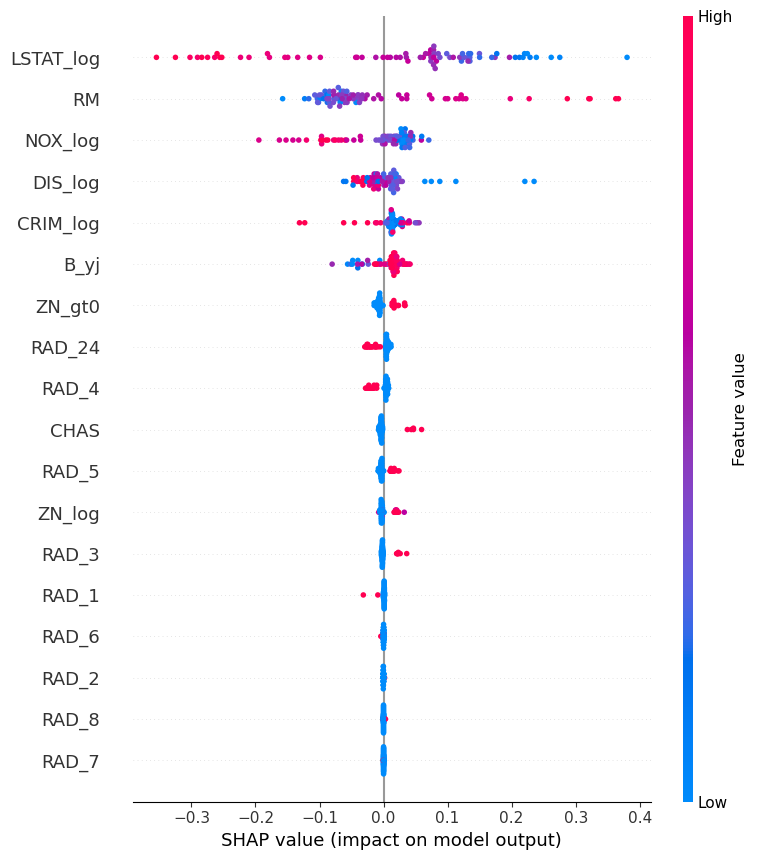

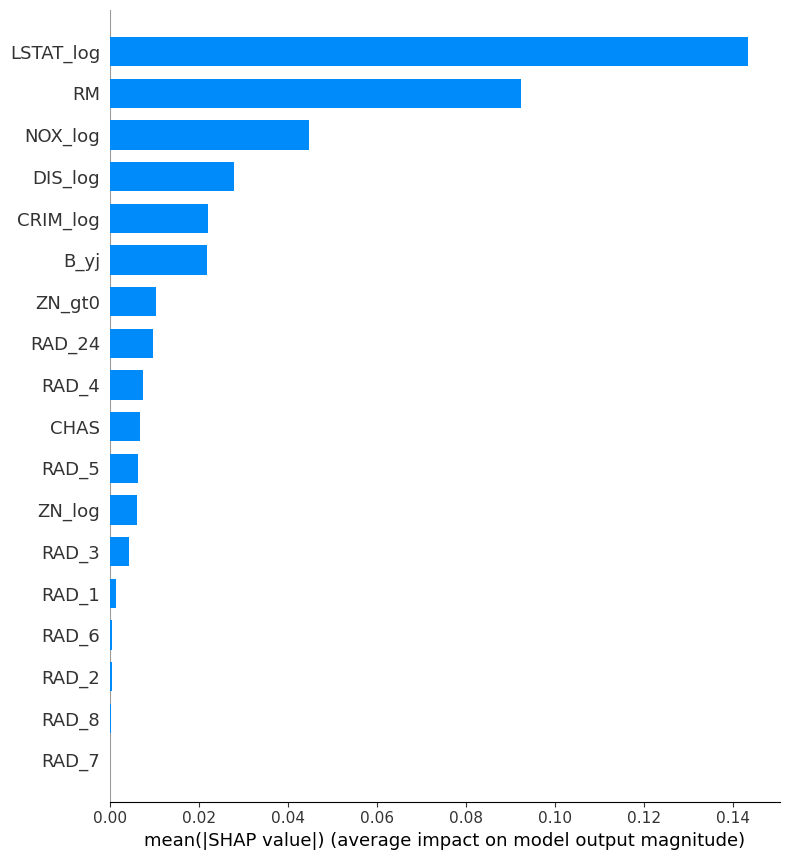

In [8]:
X_background = X_train_transformed
X_shap = X_val_transformed
cat_explainer = shap.TreeExplainer(cat_model)
cat_shap_values = cat_explainer.shap_values(X_shap)
shap.summary_plot(
    cat_shap_values,
    X_shap,
    feature_names=X_shap.columns
)
shap.summary_plot(
    cat_shap_values,
    X_shap,
    feature_names=X_shap.columns,
    plot_type="bar"
)
cat_importance = (
    pd.DataFrame({
        "feature": X_val_transformed.columns,
        "importance": np.abs(cat_shap_values).mean(axis=0)
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

cat_top10 = cat_importance.head(10)

PermutationExplainer explainer: 77it [00:28,  2.66it/s]                        
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30096\4235317806.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


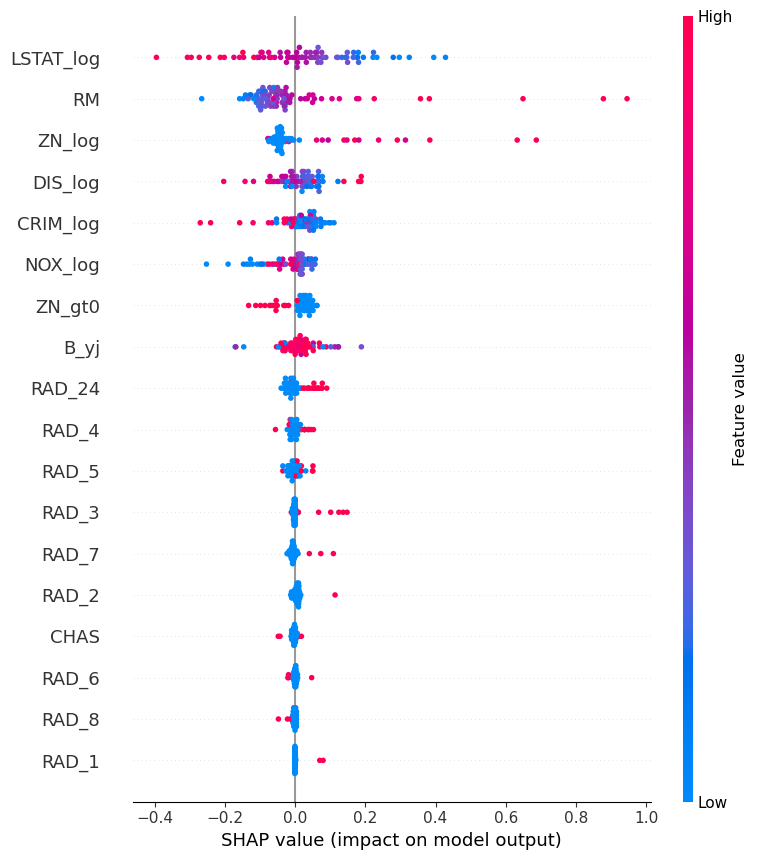

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30096\4235317806.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


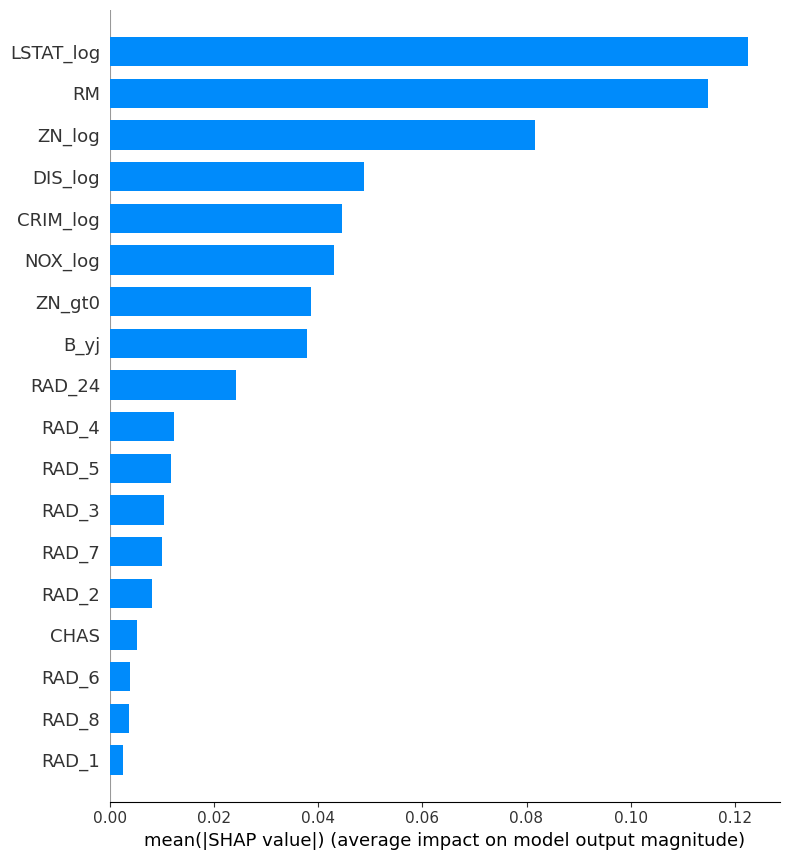

In [9]:
# SHAP for PyTorch MLP
trained_mlp.eval()

def mlp_predict(X_numpy):
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        preds = trained_mlp(X_tensor).cpu().numpy().flatten()
    return preds


# SAFE sample sizes
bg_size = min(200, len(X_train_transformed))
shap_size = min(300, len(X_val_transformed))

X_background = X_train_transformed.sample(bg_size, random_state=42).values
X_shap_df = X_val_transformed.sample(shap_size, random_state=42)
X_shap = X_shap_df.values

mlp_explainer = shap.Explainer(
    mlp_predict,
    X_background
)

mlp_shap_values = mlp_explainer(X_shap)

shap.summary_plot(
    mlp_shap_values.values,
    X_shap_df,
    feature_names=X_shap_df.columns
)

shap.summary_plot(
    mlp_shap_values.values,
    X_shap_df,
    feature_names=X_shap_df.columns,
    plot_type="bar"
)
mlp_importance = (
    pd.DataFrame({
        "feature": X_shap_df.columns,
        "importance": np.abs(mlp_shap_values.values).mean(axis=0)
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

mlp_top10 = mlp_importance.head(10)


In [10]:
comparison_table = pd.DataFrame({
    "Rank": range(1, 11),
    "LightGBM": lgb_top10["feature"].values,
    "CatBoost": cat_top10["feature"].values,
    "MLP": mlp_top10["feature"].values
})

comparison_table


,Rank,LightGBM,CatBoost,MLP
0,1,LSTAT_log,LSTAT_log,LSTAT_log
1,2,RM,RM,RM
2,3,NOX_log,NOX_log,ZN_log
3,4,DIS_log,DIS_log,DIS_log
4,5,B_yj,CRIM_log,CRIM_log
5,6,CRIM_log,B_yj,NOX_log
6,7,RAD_5,ZN_gt0,ZN_gt0
7,8,RAD_3,RAD_24,B_yj
8,9,RAD_4,RAD_4,RAD_24
9,10,ZN_log,CHAS,RAD_4


LOCAL EXPLANATIONS (Log Space Consistent)
Analyzing 5 examples: [ 7 63 19 41 50]

3. Selected representative examples:
----------------------------------------------------------------------------------------------------
Example                   | Idx    | Actual ($) | Predicted ($) | Error ($)    | Log Err   
----------------------------------------------------------------------------------------------------
perfect                   | 7      | $14.00     | $16.54       | $      -2.54 |   -0.1566
under                     | 63     | $20.20     | $17.95       | $      +2.25 |   +0.1123
over                      | 19     | $14.10     | $14.77       | $      -0.67 |   -0.0432
high                      | 41     | $28.20     | $29.04       | $      -0.84 |   -0.0285
low                       | 50     | $18.90     | $19.91       | $      -1.01 |   -0.0494
----------------------------------------------------------------------------------------------------

Log Error Interpretation:
Example 7

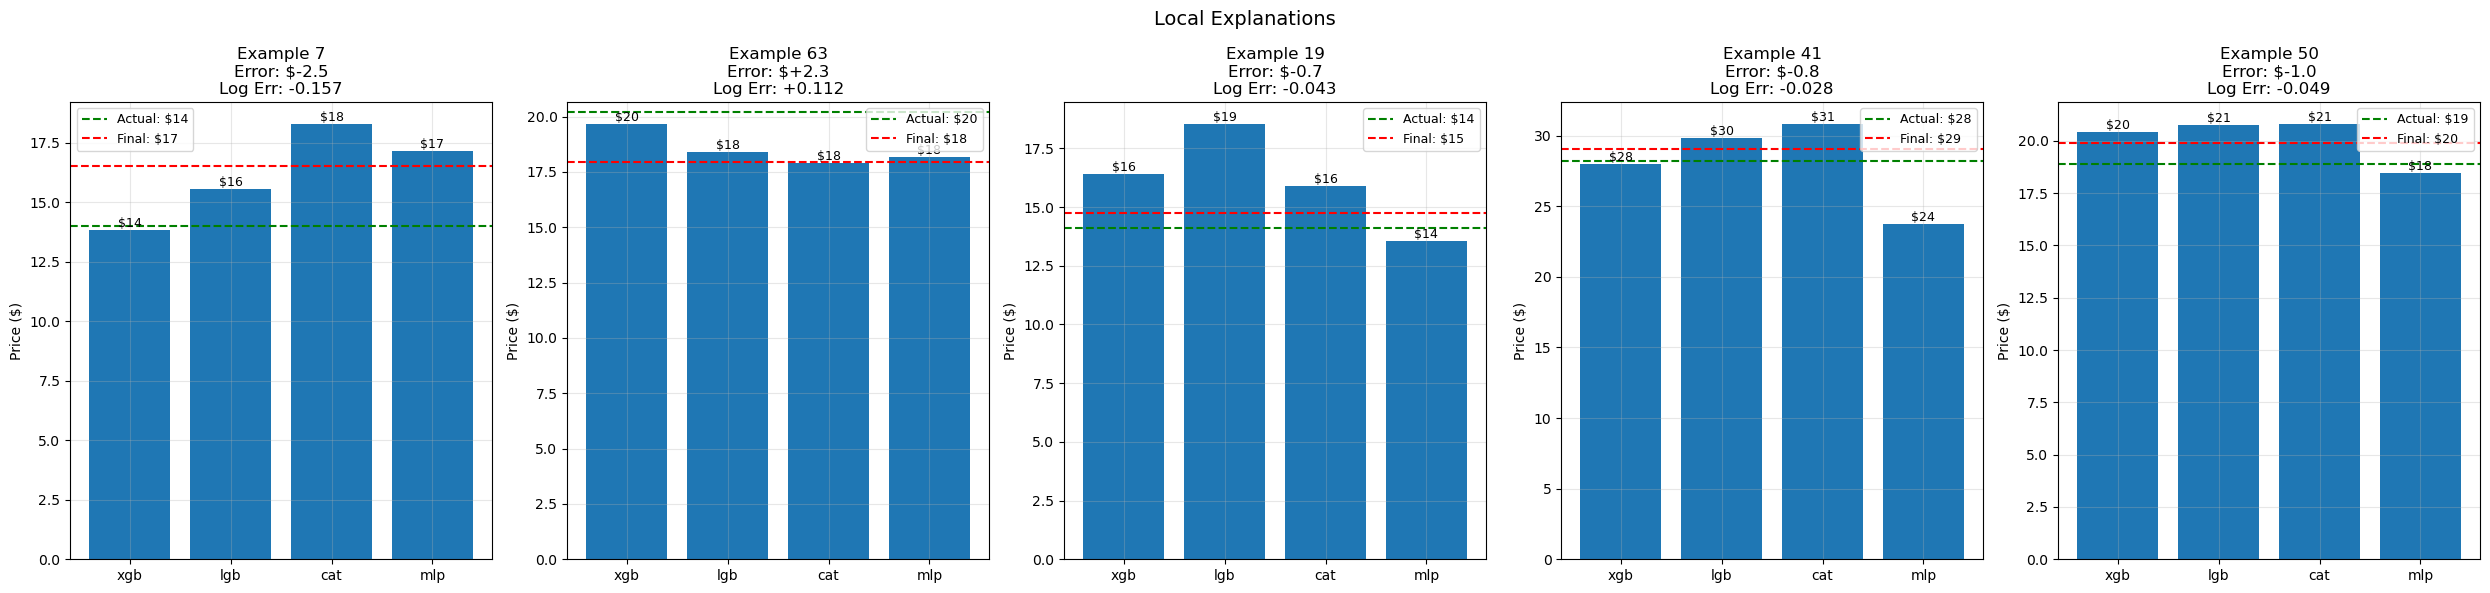

In [12]:
def get_local_explanations(model, X_test_transformed, y_test_log, indices):
    results = {}
    # Model predictions 
    pred_log = model.predict(X_test_transformed)
    # Calculate log errors
    errors_log = y_test_log - pred_log
    
    for idx in indices:
        actual_log = y_test_log.iloc[idx] if hasattr(y_test_log, 'iloc') else y_test_log[idx]
        actual_dollar = np.expm1(actual_log)
        
        predicted_log = pred_log.iloc[idx] if hasattr(pred_log, 'iloc') else pred_log[idx]
        predicted_dollar = np.expm1(predicted_log)
        
        error_log = errors_log.iloc[idx] if hasattr(errors_log, 'iloc') else errors_log[idx]
        error_dollar = actual_dollar - predicted_dollar
        
        # base model predictions
        X_single = X_test_transformed.iloc[idx:idx+1]
        base_preds_log = model._get_base_preds(X_single)
        if len(base_preds_log.shape) == 1:
            base_preds_log = base_preds_log.reshape(1, -1)
        
        results[idx] = {
            'actual': {'dollar': float(actual_dollar), 'log': float(actual_log)},
            'predicted': {'dollar': float(predicted_dollar), 'log': float(predicted_log)},
            'error': {'dollar': float(error_dollar), 'log': float(error_log)},
            'percent_error': float((error_dollar / actual_dollar * 100) if actual_dollar != 0 else 0),
            'base_models': {}
        }
        
        # base model predictions
        for i, name in enumerate(model.model_names):
            if i < base_preds_log.shape[1]:
                log_pred = base_preds_log[0, i]
                results[idx]['base_models'][name] = {
                    'log': float(log_pred),
                    'dollar': float(np.expm1(log_pred))
                }
    
    return results

def print_results_table(results):
    """results in table format."""
    print("\n3. Selected representative examples:")
    print("-" * 100)
    print(f"{'Example':<25} | {'Idx':<6} | {'Actual ($)':<10} | {'Predicted ($)':<12} | {'Error ($)':<12} | {'Log Err':<10}")
    print("-" * 100)
    
    names = ["perfect", "under", "over", "high", "low"]
    
    for i, (idx, r) in enumerate(results.items()):
        name = names[i] if i < len(names) else f"ex_{i+1}"
        print(f"{name:<25} | {idx:<6} | ${r['actual']['dollar']:<9.2f} | "
              f"${r['predicted']['dollar']:<11.2f} | ${r['error']['dollar']:>+11.2f} | "
              f"{r['error']['log']:>+9.4f}")
    print("-" * 100)

def plot_explanations(results, model_names):
    """visualization of base model contributions."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 6))
    if n == 1:
        axes = [axes]
    
    for ax, (idx, r) in zip(axes, results.items()):
        base_preds = [r['base_models'][name]['dollar'] for name in model_names if name in r['base_models']]
        base_labels = [name for name in model_names if name in r['base_models']]
        
        x_pos = range(len(base_labels))
        bars = ax.bar(x_pos, base_preds)
        
        ax.axhline(y=r['actual']['dollar'], color='green', linestyle='--', 
                  label=f'Actual: ${r["actual"]["dollar"]:.0f}')
        ax.axhline(y=r['predicted']['dollar'], color='red', linestyle='--',
                  label=f'Final: ${r["predicted"]["dollar"]:.0f}')
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(base_labels)
        ax.set_ylabel('Price ($)')
        ax.set_title(f'Example {idx}\nError: ${r["error"]["dollar"]:+.1f}\nLog Err: {r["error"]["log"]:+.3f}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        for bar, val in zip(bars, base_preds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                   f'${val:.0f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Local Explanations', fontsize=14)
    plt.tight_layout()
    plt.show()

def explain_local(model, X_test_transformed, y_test_original, indices=None, n=5):
    y_test_log = np.log1p(y_test_original)
    
    if indices is None:
        indices = np.random.choice(len(y_test_log), n, replace=False)
    
    print("="*80)
    print("LOCAL EXPLANATIONS (Log Space Consistent)")
    print("="*80)
    print(f"Analyzing {len(indices)} examples: {indices}")
    results = get_local_explanations(model, X_test_transformed, y_test_log, indices)
    print_results_table(results)
    
    # Show interpretation
    print("\nLog Error Interpretation:")
    for idx, r in results.items():
        perc = (np.exp(r['error']['log']) - 1) * 100
        print(f"Example {idx}: Log error {r['error']['log']:+.4f} ≈ {perc:+.1f}% error")
    
    plot_explanations(results, model.model_names)
    return results

results = explain_local(model, X_test_transformed, y_test, n=5)